# Quick Comparison: Hugging Face Sentiment vs GDELT Sentiment

Goal: compare two sentiment datasets on the same simple task:

**Next-Day Direction Prediction** for **Information Technology** stocks only.

We keep this intentionally simple:

- same date range: 2022 and forward, matched to the overlap between both datasets
- same target
- same feature engineering
- same train/validation split
- compare Logistic Regression, Gradient Boosting, and LSTM

## 1. Read Data

In [ ]:
from pathlib import Path
import sys
import warnings

# LOCAL_PACKAGES = Path("packages")
# if LOCAL_PACKAGES.exists() and str(LOCAL_PACKAGES) not in sys.path:
#     sys.path.insert(0, str(LOCAL_PACKAGES))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(4)

HUGGING_FACE_PATH = Path("sp500_panel_with_sentiment.csv")
GDELT_PATH = Path("final_sp500_data.csv")

hugging_face_raw = pd.read_csv(HUGGING_FACE_PATH, parse_dates=["date"])
gdelt_raw = pd.read_csv(GDELT_PATH)
gdelt_raw.columns = [c.lower() for c in gdelt_raw.columns]
gdelt_raw["date"] = pd.to_datetime(gdelt_raw["date"])

print("Hugging Face sentiment:", hugging_face_raw.shape, hugging_face_raw["date"].min().date(), "to", hugging_face_raw["date"].max().date())
print("GDELT sentiment:", gdelt_raw.shape, gdelt_raw["date"].min().date(), "to", gdelt_raw["date"].max().date())
display(hugging_face_raw.head(3))
display(gdelt_raw.head(3))

Hugging Face sentiment: (515715, 17) 2022-01-03 to 2026-02-13
GDELT sentiment: (1883792, 12) 2010-01-04 to 2025-11-10


,date,ticker,close,high,low,open,volume,company,sector,industry,article_count,pos_prob_mean,neg_prob_mean,neu_prob_mean,positive_count,negative_count,neutral_count
0,2022-01-03,A,152.048294,154.924470,149.570510,154.496929,1606300.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-04,A,146.908142,151.222399,145.460335,151.086365,2234000.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-05,A,144.391479,148.764034,144.323455,146.558319,2370500.0,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,0,NaN,NaN,NaN,NaN,NaN,NaN


,date,ticker,company,sector,industry,open,high,low,close,volume,avg_sentiment,article_count
0,2021-07-15,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.837958,50.460862,49.628436,50.024830,2752650,1.672467,3
1,2021-07-16,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.928565,50.449540,49.543499,49.611450,2798850,2.251032,2
2,2021-07-19,PCAR,Paccar Inc,Industrials,Construction Machinery & Heavy Transportation ...,49.084803,49.492521,48.829979,49.101791,3898500,0.000000,0


## 2. Filter to 2022+ and Matched Overlap

In [2]:
START_DATE = pd.Timestamp("2022-01-01")
END_DATE = min(hugging_face_raw["date"].max(), gdelt_raw["date"].max())

hugging_face = hugging_face_raw[(hugging_face_raw["date"] >= START_DATE) & (hugging_face_raw["date"] <= END_DATE)].copy()
gdelt = gdelt_raw[(gdelt_raw["date"] >= START_DATE) & (gdelt_raw["date"] <= END_DATE)].copy()

# Normalize sentiment column names so the rest of the notebook can use one feature builder.
hugging_face["sentiment_score_raw"] = hugging_face["pos_prob_mean"] - hugging_face["neg_prob_mean"]
gdelt["sentiment_score_raw"] = gdelt["avg_sentiment"]

hugging_face["source"] = "Hugging Face sentiment"
gdelt["source"] = "GDELT sentiment"

common_keys = set(zip(hugging_face["date"], hugging_face["ticker"])) & set(zip(gdelt["date"], gdelt["ticker"]))
hugging_face = hugging_face[[key in common_keys for key in zip(hugging_face["date"], hugging_face["ticker"])]].copy()
gdelt = gdelt[[key in common_keys for key in zip(gdelt["date"], gdelt["ticker"])]].copy()

print(f"Matched date range: {START_DATE.date()} to {END_DATE.date()}")
print(f"Common (date, ticker) rows: {len(common_keys):,}")
print("Hugging Face matched rows:", len(hugging_face))
print("GDELT matched rows:", len(gdelt))

Matched date range: 2022-01-01 to 2025-11-10
Common (date, ticker) rows: 473,828
Hugging Face matched rows: 473828
GDELT matched rows: 473828


## 3. Simple EDA: News Coverage by Sector

,sector,rows,article_coverage,source
11,Communication Services,22264,0.280632,GDELT sentiment
0,Communication Services,22264,0.290110,Hugging Face sentiment
12,Consumer Discretionary,45496,0.299191,GDELT sentiment
1,Consumer Discretionary,45496,0.258308,Hugging Face sentiment
13,Consumer Staples,33545,0.282874,GDELT sentiment
2,Consumer Staples,33545,0.282904,Hugging Face sentiment
14,Energy,21296,0.310011,GDELT sentiment
3,Energy,21296,0.360208,Hugging Face sentiment
15,Financials,69696,0.312041,GDELT sentiment
4,Financials,69696,0.247733,Hugging Face sentiment


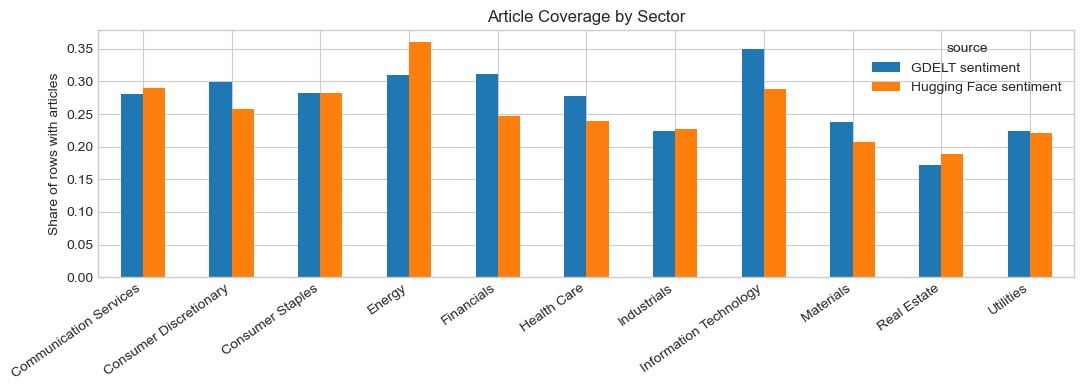

In [3]:
def sector_coverage(df, source_name):
    out = (
        df.assign(has_articles=df["article_count"] > 0)
        .groupby("sector")
        .agg(rows=("ticker", "size"), article_coverage=("has_articles", "mean"))
        .reset_index()
    )
    out["source"] = source_name
    return out

coverage = pd.concat([
    sector_coverage(hugging_face, "Hugging Face sentiment"),
    sector_coverage(gdelt, "GDELT sentiment"),
], ignore_index=True)

display(coverage.sort_values(["sector", "source"]))

fig, ax = plt.subplots(figsize=(11, 4))
pivot = coverage.pivot(index="sector", columns="source", values="article_coverage").sort_index()
pivot.plot(kind="bar", ax=ax)
ax.set_title("Article Coverage by Sector")
ax.set_ylabel("Share of rows with articles")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 4. Feature Engineering, Tech-Only Filter, and Split

In [4]:
TRAIN_END = pd.Timestamp("2024-06-30")
VALID_END = pd.Timestamp("2025-06-30")
TARGET = "next_day_direction"

FEATURES = [
    "return_1d",
    "return_5d",
    "price_mean_5d",
    "price_mean_10d",
    "return_vol_5d",
    "volume_pct_change_1d",
    "sentiment_score",
    "sentiment_mean_5d",
    "has_articles",
    "return_1d_minus_date_mean",
    "return_5d_minus_date_mean",
    "sentiment_score_minus_date_mean",
    "log_article_count",
    "article_count_rank_date",
    "article_count_minus_date_mean",
    "rolling_article_count_5d",
    "rolling_has_articles_5d",
]


def build_model_table(df):
    keep = [
        "date", "ticker", "close", "high", "low", "open", "volume",
        "company", "sector", "industry", "article_count", "sentiment_score_raw", "source",
    ]
    df = df[keep].sort_values(["ticker", "date"]).reset_index(drop=True).copy()
    by_ticker = df.groupby("ticker", group_keys=False)

    next_close = by_ticker["close"].shift(-1)
    df[TARGET] = pd.Series(pd.NA, index=df.index, dtype="Int64")
    valid_next = next_close.notna()
    df.loc[valid_next, TARGET] = (next_close[valid_next] > df.loc[valid_next, "close"]).astype(int)

    df["return_1d"] = by_ticker["close"].pct_change(1)
    df["return_5d"] = by_ticker["close"].pct_change(5)
    df["price_mean_5d"] = by_ticker["close"].transform(lambda s: s.rolling(5, min_periods=5).mean())
    df["price_mean_10d"] = by_ticker["close"].transform(lambda s: s.rolling(10, min_periods=10).mean())
    df["return_vol_5d"] = by_ticker["return_1d"].transform(lambda s: s.rolling(5, min_periods=5).std())
    df["volume_pct_change_1d"] = by_ticker["volume"].pct_change(1)

    df["has_articles"] = (df["article_count"] > 0).astype(int)
    df["sentiment_score"] = df["sentiment_score_raw"].fillna(0).mask(df["article_count"] == 0, 0.0)
    df["sentiment_mean_5d"] = by_ticker["sentiment_score"].transform(lambda s: s.rolling(5, min_periods=5).mean())

    df["return_1d_minus_date_mean"] = df["return_1d"] - df.groupby("date")["return_1d"].transform("mean")
    df["return_5d_minus_date_mean"] = df["return_5d"] - df.groupby("date")["return_5d"].transform("mean")
    df["sentiment_score_minus_date_mean"] = df["sentiment_score"] - df.groupby("date")["sentiment_score"].transform("mean")

    df["log_article_count"] = np.log1p(df["article_count"])
    df["article_count_rank_date"] = df.groupby("date")["article_count"].rank(pct=True)
    df["article_count_minus_date_mean"] = df["article_count"] - df.groupby("date")["article_count"].transform("mean")
    df["rolling_article_count_5d"] = by_ticker["article_count"].transform(lambda s: s.rolling(5, min_periods=5).mean())
    df["rolling_has_articles_5d"] = by_ticker["has_articles"].transform(lambda s: s.rolling(5, min_periods=5).mean())

    df["split"] = "test"
    df.loc[df["date"] <= TRAIN_END, "split"] = "train"
    df.loc[(df["date"] > TRAIN_END) & (df["date"] <= VALID_END), "split"] = "validation"

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES).reset_index(drop=True)
    return df[df["sector"] == "Information Technology"].copy()


hugging_face_model = build_model_table(hugging_face)
gdelt_model = build_model_table(gdelt)

for name, data in [("Hugging Face", hugging_face_model), ("GDELT", gdelt_model)]:
    print(name, data.shape)
    display(data["split"].value_counts().reindex(["train", "validation", "test"]).to_frame("rows"))

Hugging Face (65214, 32)


,rows
split,
train,41888
validation,17000
test,6326


GDELT (65214, 32)


,rows
split,
train,41888
validation,17000
test,6326


In [5]:
def split_xy(df, split):
    subset = df[(df["split"] == split) & df[TARGET].notna()].copy()
    subset[TARGET] = subset[TARGET].astype(int)
    return subset


def score(y_true, probs):
    preds = (probs >= 0.5).astype(int)
    return roc_auc_score(y_true, probs), f1_score(y_true, preds, zero_division=0)

## 5. Logistic Regression

In [6]:
logistic_grid = [
    {"C": 0.1, "class_weight": None},
    {"C": 0.3, "class_weight": None},
    {"C": 1.0, "class_weight": None},
    {"C": 1.0, "class_weight": "balanced"},
]

def run_logistic(data):
    train = split_xy(data, "train")
    valid = split_xy(data, "validation")
    rows = []
    for params in logistic_grid:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42, **params)),
        ])
        model.fit(train[FEATURES], train[TARGET])
        probs = model.predict_proba(valid[FEATURES])[:, 1]
        auc, f1 = score(valid[TARGET], probs)
        rows.append({"params": params, "roc_auc": auc, "f1": f1})
    return max(rows, key=lambda x: (x["roc_auc"], x["f1"]))

lr_hugging_face = run_logistic(hugging_face_model)
lr_gdelt = run_logistic(gdelt_model)
print("Hugging Face:", lr_hugging_face)
print("GDELT:", lr_gdelt)

Hugging Face: {'params': {'C': 0.1, 'class_weight': None}, 'roc_auc': 0.5028692818941501, 'f1': 0.5617604318040273}
GDELT: {'params': {'C': 0.1, 'class_weight': None}, 'roc_auc': 0.5078619014691756, 'f1': 0.5478413709766011}


## 6. Gradient Boosting

In [7]:
gb_grid = [
    {"n_estimators": 50, "learning_rate": 0.10, "max_depth": 2, "min_samples_leaf": 25, "subsample": 0.8},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 25, "subsample": 0.9},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 50, "subsample": 0.8},
]

def run_gb(data):
    train = split_xy(data, "train")
    valid = split_xy(data, "validation")
    rows = []
    for params in gb_grid:
        model = GradientBoostingClassifier(random_state=42, **params)
        model.fit(train[FEATURES], train[TARGET])
        probs = model.predict_proba(valid[FEATURES])[:, 1]
        auc, f1 = score(valid[TARGET], probs)
        rows.append({"params": params, "roc_auc": auc, "f1": f1})
    return max(rows, key=lambda x: (x["roc_auc"], x["f1"]))

gb_hugging_face = run_gb(hugging_face_model)
gb_gdelt = run_gb(gdelt_model)
print("Hugging Face:", gb_hugging_face)
print("GDELT:", gb_gdelt)

Hugging Face: {'params': {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 25, 'subsample': 0.8}, 'roc_auc': 0.5007922842670695, 'f1': 0.45492860288104675}
GDELT: {'params': {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 25, 'subsample': 0.9}, 'roc_auc': 0.4926255238987013, 'f1': 0.5911480737979161}


## 7. LSTM

In [8]:
class SmallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=layers,
            dropout=dropout if layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.out(self.dropout(output[:, -1, :])).squeeze(1)


def make_sequences(data, seq_len, split, scaler):
    scaled = data[data[TARGET].notna()].copy()
    scaled[TARGET] = scaled[TARGET].astype(int)
    scaled[FEATURES] = scaler.transform(scaled[FEATURES])
    xs, ys = [], []
    for _, group in scaled.groupby("ticker", sort=False):
        group = group.sort_values("date")
        values = group[FEATURES].to_numpy(dtype=np.float32)
        labels = group[TARGET].to_numpy(dtype=np.float32)
        splits = group["split"].to_numpy()
        for i in range(seq_len - 1, len(group)):
            if splits[i] != split:
                continue
            if not np.all(splits[i - seq_len + 1 : i + 1] == split):
                continue
            xs.append(values[i - seq_len + 1 : i + 1])
            ys.append(labels[i])
    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


def predict_lstm(model, x, batch_size):
    model.eval()
    probs = []
    loader = DataLoader(TensorDataset(torch.tensor(x)), batch_size=batch_size)
    with torch.no_grad():
        for (batch_x,) in loader:
            probs.append(torch.sigmoid(model(batch_x)).numpy())
    return np.concatenate(probs)


lstm_grid = [
    {"seq_len": 5, "hidden_size": 32, "layers": 1, "dropout": 0.0, "lr": 0.001, "batch_size": 128},
    {"seq_len": 5, "hidden_size": 64, "layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 128},
]

def run_lstm(data):
    train = split_xy(data, "train")
    scaler = StandardScaler().fit(train[FEATURES])
    rows = []
    for config in lstm_grid:
        train_x, train_y = make_sequences(data, config["seq_len"], "train", scaler)
        valid_x, valid_y = make_sequences(data, config["seq_len"], "validation", scaler)
        model = SmallLSTM(train_x.shape[2], config["hidden_size"], config["layers"], config["dropout"])
        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=1e-4)
        criterion = nn.BCEWithLogitsLoss()
        loader = DataLoader(
            TensorDataset(torch.tensor(train_x), torch.tensor(train_y)),
            batch_size=config["batch_size"],
            shuffle=True,
        )
        best_auc, best_f1, best_epoch = -1, 0, 0
        misses = 0
        for epoch in range(1, 16):
            model.train()
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                loss = criterion(model(batch_x), batch_y)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            probs = predict_lstm(model, valid_x, config["batch_size"])
            auc, f1 = score(valid_y, probs)
            if auc > best_auc:
                best_auc, best_f1, best_epoch = auc, f1, epoch
                misses = 0
            else:
                misses += 1
                if misses >= 3:
                    break
        rows.append({"params": {**config, "best_epoch": best_epoch}, "roc_auc": best_auc, "f1": best_f1})
    return max(rows, key=lambda x: (x["roc_auc"], x["f1"]))

lstm_hugging_face = run_lstm(hugging_face_model)
lstm_gdelt = run_lstm(gdelt_model)
print("Hugging Face:", lstm_hugging_face)
print("GDELT:", lstm_gdelt)

Hugging Face: {'params': {'seq_len': 5, 'hidden_size': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128, 'best_epoch': 2}, 'roc_auc': 0.5190328306826386, 'f1': 0.6413627942704804}
GDELT: {'params': {'seq_len': 5, 'hidden_size': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128, 'best_epoch': 6}, 'roc_auc': 0.506738196402768, 'f1': 0.6294039492371833}


## 8. Final Comparison Table

,Sentiment source,Model,roc_auc,f1,params
2,Hugging Face,LSTM,0.5190,0.6414,"{'seq_len': 5, 'hidden_size': 32, 'layers': 1,..."
3,GDELT,Logistic Regression,0.5079,0.5478,"{'C': 0.1, 'class_weight': None}"
5,GDELT,LSTM,0.5067,0.6294,"{'seq_len': 5, 'hidden_size': 32, 'layers': 1,..."
0,Hugging Face,Logistic Regression,0.5029,0.5618,"{'C': 0.1, 'class_weight': None}"
1,Hugging Face,Gradient Boosting,0.5008,0.4549,"{'n_estimators': 50, 'learning_rate': 0.1, 'ma..."
4,GDELT,Gradient Boosting,0.4926,0.5911,"{'n_estimators': 100, 'learning_rate': 0.05, '..."


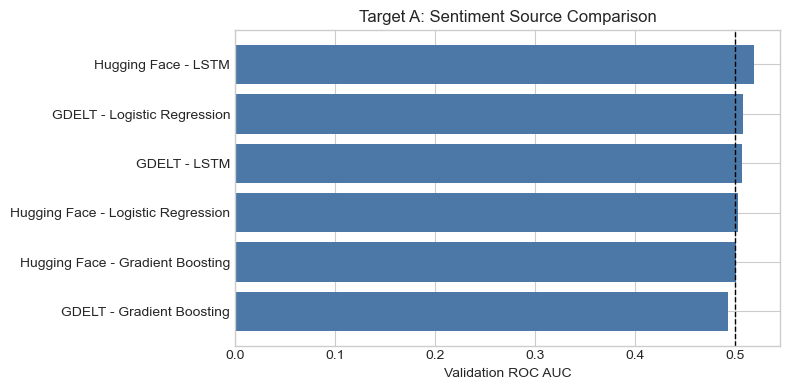

In [9]:
results = pd.DataFrame([
    {"Sentiment source": "Hugging Face", "Model": "Logistic Regression", **lr_hugging_face},
    {"Sentiment source": "Hugging Face", "Model": "Gradient Boosting", **gb_hugging_face},
    {"Sentiment source": "Hugging Face", "Model": "LSTM", **lstm_hugging_face},
    {"Sentiment source": "GDELT", "Model": "Logistic Regression", **lr_gdelt},
    {"Sentiment source": "GDELT", "Model": "Gradient Boosting", **gb_gdelt},
    {"Sentiment source": "GDELT", "Model": "LSTM", **lstm_gdelt},
])

display_results = results.copy()
display_results["roc_auc"] = display_results["roc_auc"].map(lambda x: f"{x:.4f}")
display_results["f1"] = display_results["f1"].map(lambda x: f"{x:.4f}")
display(display_results[["Sentiment source", "Model", "roc_auc", "f1", "params"]].sort_values("roc_auc", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = results.copy()
plot_df["label"] = plot_df["Sentiment source"] + " - " + plot_df["Model"]
plot_df = plot_df.sort_values("roc_auc")
ax.barh(plot_df["label"], plot_df["roc_auc"], color="#4c78a8")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Validation ROC AUC")
ax.set_title("Target A: Sentiment Source Comparison")
plt.tight_layout()
plt.show()